<div style="border:solid Chocolate 2px; padding: 40px">

<b> Валерия, привет!👋</b>

Меня зовут Алексей Гриб, и я буду ревьюером твоего профекта. 

Сразу хочу предложить в дальнейшем общаться на "ты" - надеюсь, так будет комфортнее:) Но если это неудобно, обязательно дай знать, и мы придумаем что-нибудь ещё!
    
Цель ревью - не искать ошибки в твоём проекте, а помочь тебе сделать твою работу ещё лучше, устранив недочёты и приблизив её к реальным задачам специалиста по работе с данными. Поэтому не расстраивайся, если что-то не получилось с первого раза - это нормально, и это поможет тебе вырасти!
    
Ты можешь найти мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> похвала, рекомендации «со звёздочкой», полезные лайфхаки, которые сделают и без того красивое решение ещё более элегантным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации⚠️:</b> некритичные ошибки или развивающие рекомендации на будущее. 
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b>
критичные ошибки, которые обязательно нужно исправить.
</div>

    
Пожалуйста, не удаляй мои комментарии, они будут особенно полезны для нашей работы в случае повторной проверки проекта. 
    
Ты также можешь задавать свои вопросы, реагировать на мои комментарии, делать пометки и пояснения - полная творческая свобода! Но маленькая просьба - пускай они будут отличаться от моих комментариев, это поможет избежать путаницы в нашем общении:)
Например, вот так:
    
<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

*твой текст*
</div>
    
Давай посмотрим на твой проект!

#  Прогнозирование заказов такси

<font size="3"> Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, необходимо спрогнозировать количество заказов такси на следующий час.

**План проведения исследования**:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Хорошее вступление!
    
В нём есть всё, что необходимо, чтобы понять суть проекта с первых строк отчёта!

## Загрузка данных и библиотек

###  Импорт библиотек

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno optuna optuna-integration matplotlib==3.8.3 scikit-learn==1.3.0 pystan statsforecast prophet==1.1.5 statsmodels==0.14.0 holidays==0.56 datasetsforecast mlforecast numpy==1.23.0 -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import logging
import os
import random
import time
import warnings
from warnings import simplefilter


import holidays
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from pylab import rcParams
from statsforecast import StatsForecast
from statsforecast.arima import arima_string
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, kpss
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, train_test_split

import optuna
from optuna import distributions, Trial
from optuna.samplers import TPESampler
from prophet import Prophet

from mlforecast import MLForecast
from mlforecast.auto import (
    AutoMLForecast,
    AutoModel,
    AutoRidge,
    AutoRandomForest,
    AutoCatboost,
    catboost_space,
    random_forest_space,
    ridge_space,
)
from mlforecast.lag_transforms import (
    ExpandingMean,
    RollingMax,
    RollingMean,
    RollingMin,
    RollingQuantile,
    RollingStd,
    SeasonalRollingMax,
    SeasonalRollingMean,
    SeasonalRollingMin,
    SeasonalRollingQuantile,
    SeasonalRollingStd,
)
from mlforecast.target_transforms import LocalStandardScaler

from datasetsforecast.losses import rmse as datasets_rmse
from utilsforecast.losses import rmse as utils_rmse
from utilsforecast.plotting import plot_series

In [3]:
# настройки Pandas
pd.options.display.float_format ='{:,.3f}'.format
pd.set_option('display.max_columns', None)

# константы
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
PATH_LOCAL = '/Users/kasper/Documents/TS/'   
PATH_REMOTE = '/datasets/'

# настройки графиков
PLOT_DPI = 150
sns.set_theme(style="darkgrid", palette="crest")
rcParams['figure.figsize'] = 12, 6
plt.rc(
       'axes',
       labelweight='bold',
       titlesize=16,
       titlepad=10,
      )

# остальные настройки
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").disabled=True
# для корректной работы AutoCatboost
pd.DataFrame.iteritems = pd.DataFrame.items

# путь к директориям
PATH_REMOTE = '/datasets/taxi.csv'
PATH_LOCAL = '/Users/kasper/Documents/TS/taxi.csv'

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Библиотеки импортировали - отлично!

### Чтение данных

<font size="3"> Считаем исторические данные о заказах такси в аэропортах и сохраним в переменную `taxi`:

In [4]:
if os.path.exists(PATH_REMOTE):
    taxi = pd.read_csv(PATH_REMOTE, index_col=[0], parse_dates=[0])
    display(taxi.head(20))
elif os.path.exists(PATH_LOCAL):
    taxi = pd.read_csv(PATH_LOCAL, index_col=[0], parse_dates=[0])
    display(taxi.head(20))
else:
    print('Данные недоступны')

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
    
Данные загрузили - отлично! Круто, что сразу парсишь дату и делаешь её индексом:)
    
Здорово, что ты используешь конструкцию ``try-except`` для путей файлов. Но еще лучше использовать библиотеку `os` - её использование позволит тебе проверять существование указанных директорий (что может быть актуально при одновременной работа на локальном и сетевом окружении) и загружать данные из существующей директории, избегая ошибок. Как пример:
 
    import os

    pth1 = '/folder_1/data.csv'
    pth2 = '/folder_2/data.csv'
    
    if os.path.exists(pth1):
        query_1 = pd.read_csv(pth1)
    elif os.path.exists(pth2):
        query_1 = pd.read_csv(pth2)
    else:
        print('Something is wrong')

### Изучение данных

<font size="3"> Изучим структуру и полноту полученных данных.

In [5]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


<Axes: >

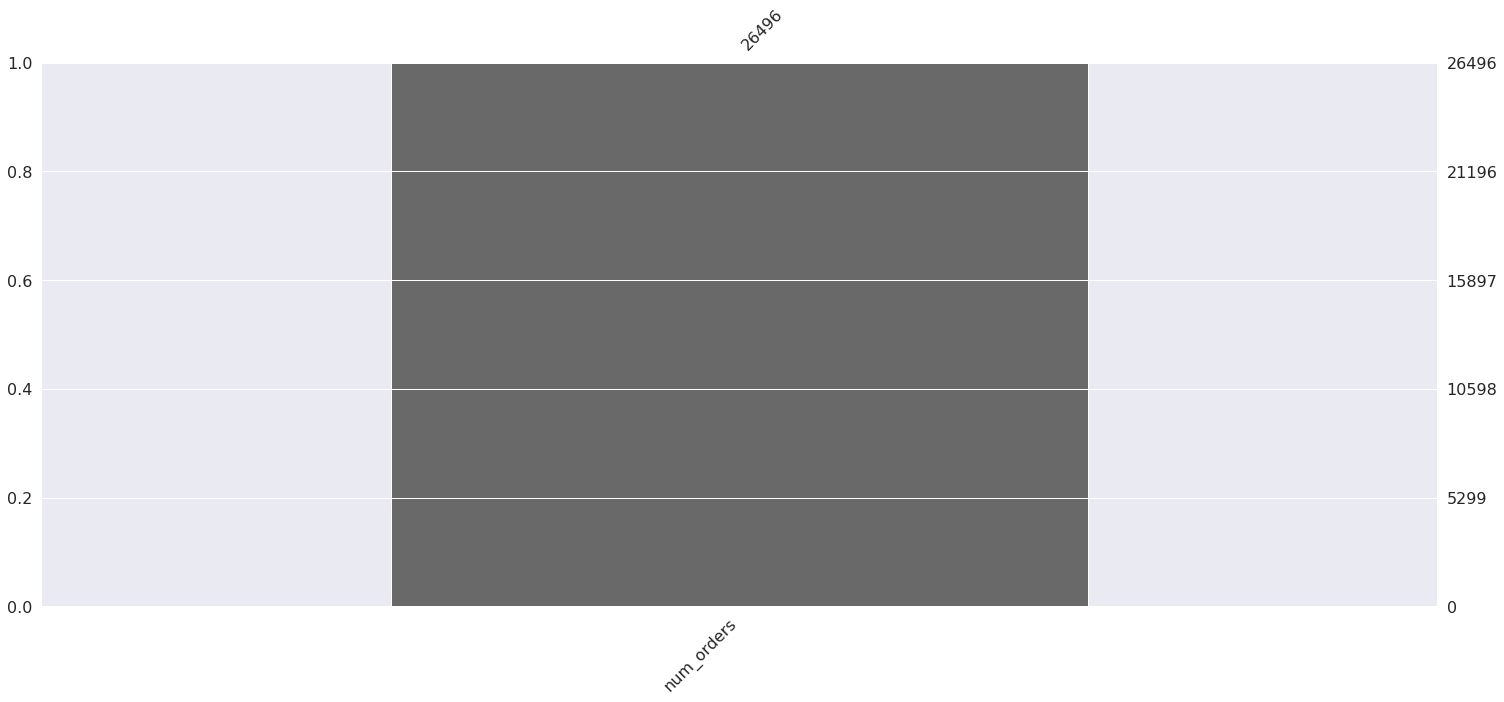

In [6]:
msno.bar(taxi)

<font size="3">
    
**Вывод**
    
Полученный датафрейм содержит следующие данные:

* `num_orders` — количество заказов такси - целевой признак, числовой дискретный признак.
    
Дата и время заказа записаны в индекс и приведены к типу `datetime64` при чтении данных.
    
Предварительно можно утверждать, что данных достаточно для проведения исследования. 

## Анализ и обработка данных

<font size="3"> Изучим подробнее полученные данные.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Дубликаты

<font size="3"> 
<br>Проверим датафрейм на наличие дубликатов в индексе.

In [7]:
print(f'Количество дубликатов: {taxi.index.duplicated().sum()}')

Количество дубликатов: 0


<font size="3">

**Вывод**
    
Дубликаты отсутствуют.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Сортировка данных
<font size="3">   
<br>Отсортируем данные по индексу для дальнейшей проверки хронологии.

In [8]:
taxi.sort_index(ascending=True, inplace=True)

<font size="3">

**Вывод**
    
Данные отсортированы.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Хронология и полнота данных
<font size="3">   
<br>Проверим хронологический порядок и наличие пропущенных промежутков в данных.

In [9]:
# проверим хронологический порядок данных
if taxi.index.is_monotonic_increasing:
    # создадим ожидаемый диапазон дат с 10-минутным шагом
    expected_timestamps = pd.date_range(
        start=taxi.index.min(), end=taxi.index.max(), freq="10T"
    )

    # найдём разницу между ожидаемым диапазоном и фактическим индексом
    missing_timestamps = expected_timestamps.difference(taxi.index)

    # проверим наличие пропущенных промежутков
    if missing_timestamps.shape[0] > 0:
        raise ValueError(
            f"Данные представлены в хронологическом порядке, но имеются пропущенные промежутки времени: {missing_timestamps.tolist()}"
        )

    print("Данные представлены в хронологическом порядке, нет пропущенных промежутков времени")
else:
    print("Хронологический порядок в данных нарушен, проверьте данные")

Данные представлены в хронологическом порядке, нет пропущенных промежутков времени


<font size="3">

**Вывод**
    
Проверена хронология и полнота данных: временной ряд представлен в хронологическом порядке, пропущенные промежутки времени отсутствуют.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Временной диапазон
    
<font size="3">   
<br>Получим период времени, который покрывают полученные данные.

In [10]:
print(f'В датасете представлено {taxi.shape[0]} записей в промежутке с {taxi.index.min()} по {taxi.index.max()}')

В датасете представлено 26496 записей в промежутке с 2018-03-01 00:00:00 по 2018-08-31 23:50:00


<font size="3">

**Вывод**
    
В датасете представлено 26 496 объектов в промежутке с 01 марта по 31 августа 2018 года - это довольно маленький временной промежуток для анализа временного ряда, что может вызвать трудности с выявлением тренда, сезонных колебаний и ежегодных циклов.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Временные интервалы
<font size="3">   
<br>Получим временные интервалы между наблюдениями в датафрейме. 

In [11]:
# вычислим разницу между последовательными временными метками
time_differences = taxi.index.to_series().diff()

# получим уникальные интервалы, исключая NaT первого элемента
unique_intervals = time_differences.dropna().unique()

# переведём интервалы в минуты
unique_intervals_minutes = unique_intervals.total_seconds() / 60

# выведем результат
print("Количество уникальных интервалов:")
print(time_differences.nunique())

print("\nИнтервал (в минутах):")
print(unique_intervals_minutes)

Количество уникальных интервалов:
1

Интервал (в минутах):
[10.]


<font size="3">

**Вывод**
    
Временной интервал между объектами фиксированный и составляет 10 минут.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Достаточно глубокий первичный анализ данных, молодец!

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Ресемплирование данных
    
<font size="3">   
<br>Интервал между наблюдениями составляет 10 минут, нам же необходимо спрогнозировать количество заказов такси на следующий час. Проведем ресемплирование данных по одному часу и суммируем количество заказов.

In [12]:
taxi = taxi.resample('1H').sum()

# проверим результат
taxi.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


<font size="3">

**Вывод**
    
Данные ресемплированы, временной интервал между объектами теперь составляет 1 час.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> 
    
Выполнили ресэмплирование данных с градацией по часу с применением функции суммирования - отличное и наиболее логичное решение для этой задачи!
</div>

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Визуализация целевого признака
    
<font size="3">   
<br>Исследуем целевой признак: построим гистограмму распределения, коробчатую диаграмму и выведем общие статистики.

count   4,416.000
mean       84.423
std        45.024
min         0.000
25%        54.000
50%        78.000
75%       107.000
max       462.000
Name: num_orders, dtype: float64

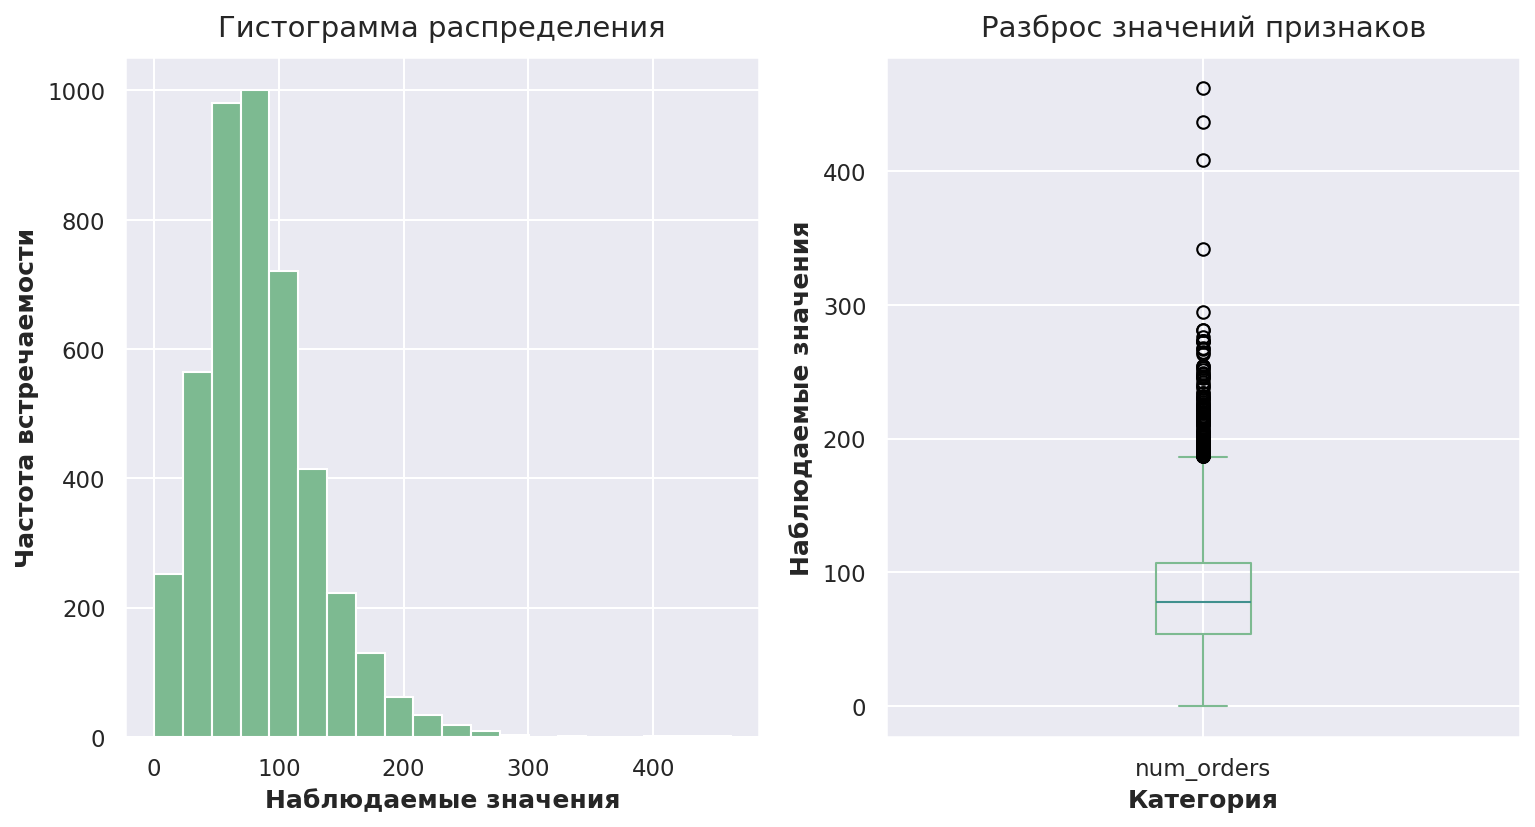

In [13]:
display(taxi['num_orders'].describe())
    
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6), dpi=PLOT_DPI)
    
taxi['num_orders'].plot(kind='hist', bins=20, ax=axes[0])
axes[0].set_title('Гистограмма распределения', fontsize=14)
axes[0].set_ylabel('Частота встречаемости')
axes[0].set_xlabel('Наблюдаемые значения')
    
taxi['num_orders'].plot(kind='box', ax=axes[1], rot=0)
axes[1].set_title('Разброс значений признаков', fontsize=14)
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Наблюдаемые значения')
plt.show()

<font size="3">

**Вывод**
    
Целевой признак `num_orders` - число заказов такси.

Распределение признака асимметрично вправо, большинство значений располагается в промежутке от 54 до 107 заказов в час с пиком в районе 80 заказов.
    
В выборке присутствуют объекты, значительно отклоняющиеся от среднего значения, но в целях сохранения полноты и хронологического порядка данных, на данном этапе исследования не будем исключать объекты из выборки.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Визуализация временного ряда
    
<font size="3">   
<br>Построим график количества заказов за весь период и добавим скользящее среднее с размером окна в 14 дней.

In [14]:
df_mean = taxi.reset_index().copy()
df_mean['rolling_mean_week'] = df_mean.num_orders.rolling(14, closed='left').mean()

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b>
При использовании `.rolling()` в такой постановке скользящее среднее считается с учётом текущего шага - это не совсем верно для задачи временных рядов, так как будет работать только для известных нам значений и сломается на предсказаниях.
        
Нужно либо использовать `.shift()` перед `.rolling()`, либо параметру `closed` при использовании `.rolling()` передать значение `left`.
    
Ниже - наглядная визуализация:
    
[![2023-07-11-15-48-51.png](https://i.postimg.cc/cH9tDwq4/2023-07-11-15-48-51.png)](https://postimg.cc/BLFvb8Qd)

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Алексей, привет! Спасибо за комментарии 🤝🏼
<br>Здесь упустила, что `.rolling()` по умолчанию включает текущий шаг, исправилась
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено.

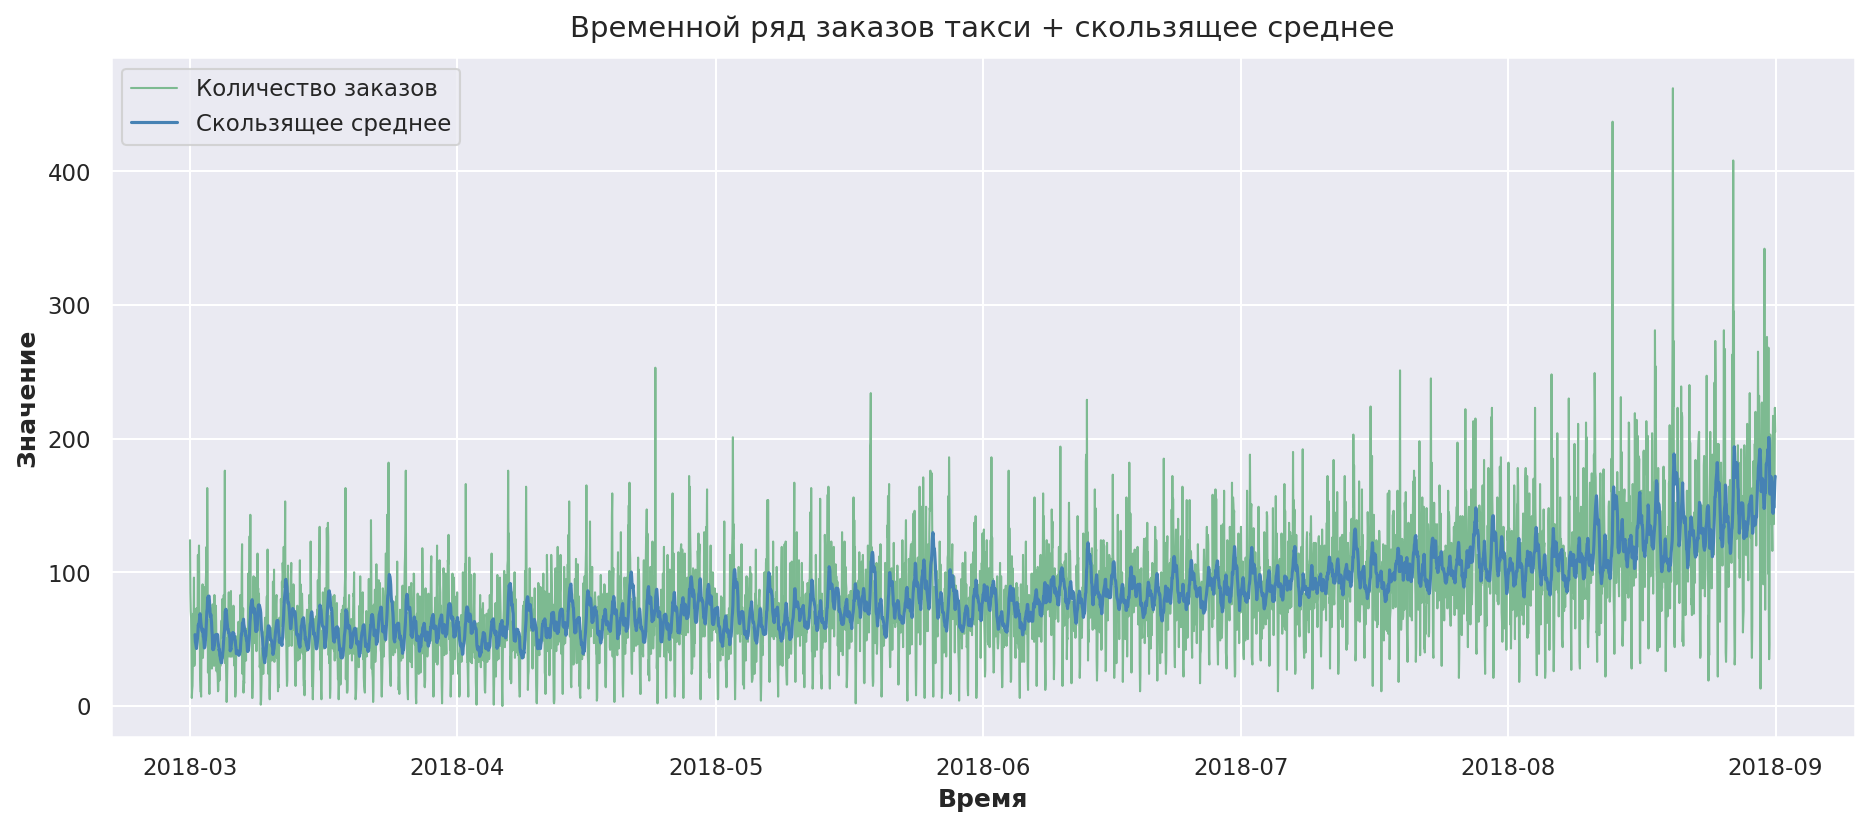

In [15]:
fig, ax = plt.subplots(figsize=(15,6), dpi=PLOT_DPI)
sns.lineplot(data=df_mean, x='datetime', y='num_orders', linewidth=1)
sns.lineplot(data=df_mean, x='datetime', y='rolling_mean_week', color='steelblue')

plt.title('Временной ряд заказов такси + скользящее среднее', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend(['Количество заказов', 'Скользящее среднее']);

<font size="3">

**Вывод**
    
Визуализация показывает восходящий тренд среднего количества заказов такси с апреля 2018 года. 
    
Дополнительно можно отметить 4 всплеска количества заказов в августе 2018. Аномалии находятся в конце временного ряда и попадут в тестовую выборку, что скажется на точности прогноза.
    
Наличие тренда говорит о том, что временной ряд нестационарен.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> Верно, ряд нестационарен.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Компоненты временного ряда
    
<font size="3">   
<br>Разложим временной ряд на две сезонные компоненты с периодом в 24 часа (суточная сезонность) и 24*7 (недельная сезонность).

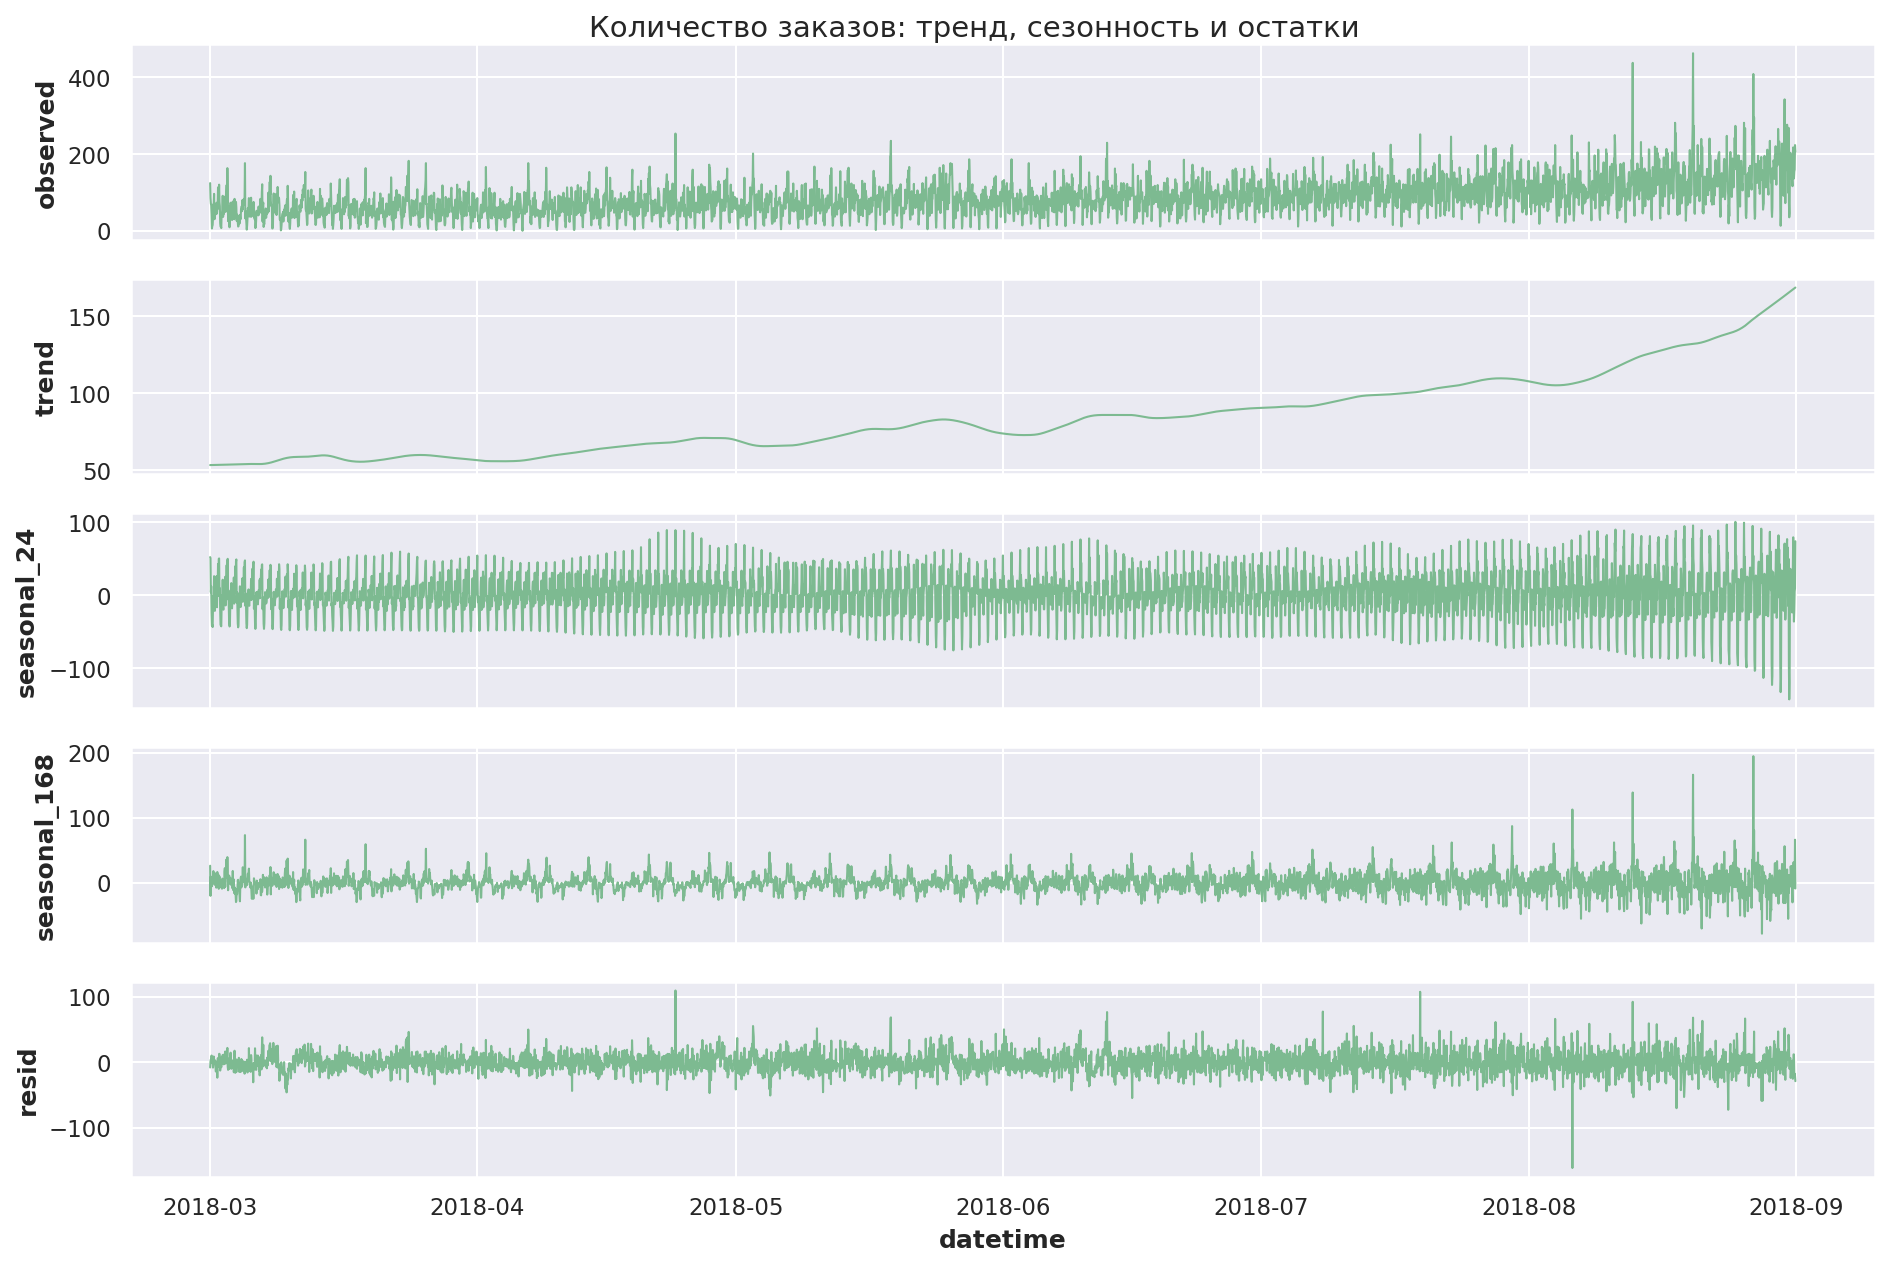

In [16]:
# обработаем данные с помощью MSTL
decomposed = MSTL(taxi, periods=(24, 24*7)).fit()

# постоим графики тренда, сезонности и остатков
fig, ax = plt.subplots(figsize=(15,10), dpi=PLOT_DPI, nrows=5, sharex=True)

sns.lineplot(data=decomposed.observed, linewidth=1, ax=ax[0])
sns.lineplot(data=decomposed.trend, linewidth=1, ax=ax[1])
sns.lineplot(data=decomposed.seasonal.seasonal_24, linewidth=1, ax=ax[2])
sns.lineplot(data=decomposed.seasonal.seasonal_168, linewidth=1, ax=ax[3])
sns.lineplot(data=decomposed.resid, linewidth=1, ax=ax[4])

plt.suptitle('Количество заказов: тренд, сезонность и остатки', fontsize=14, y=0.9);

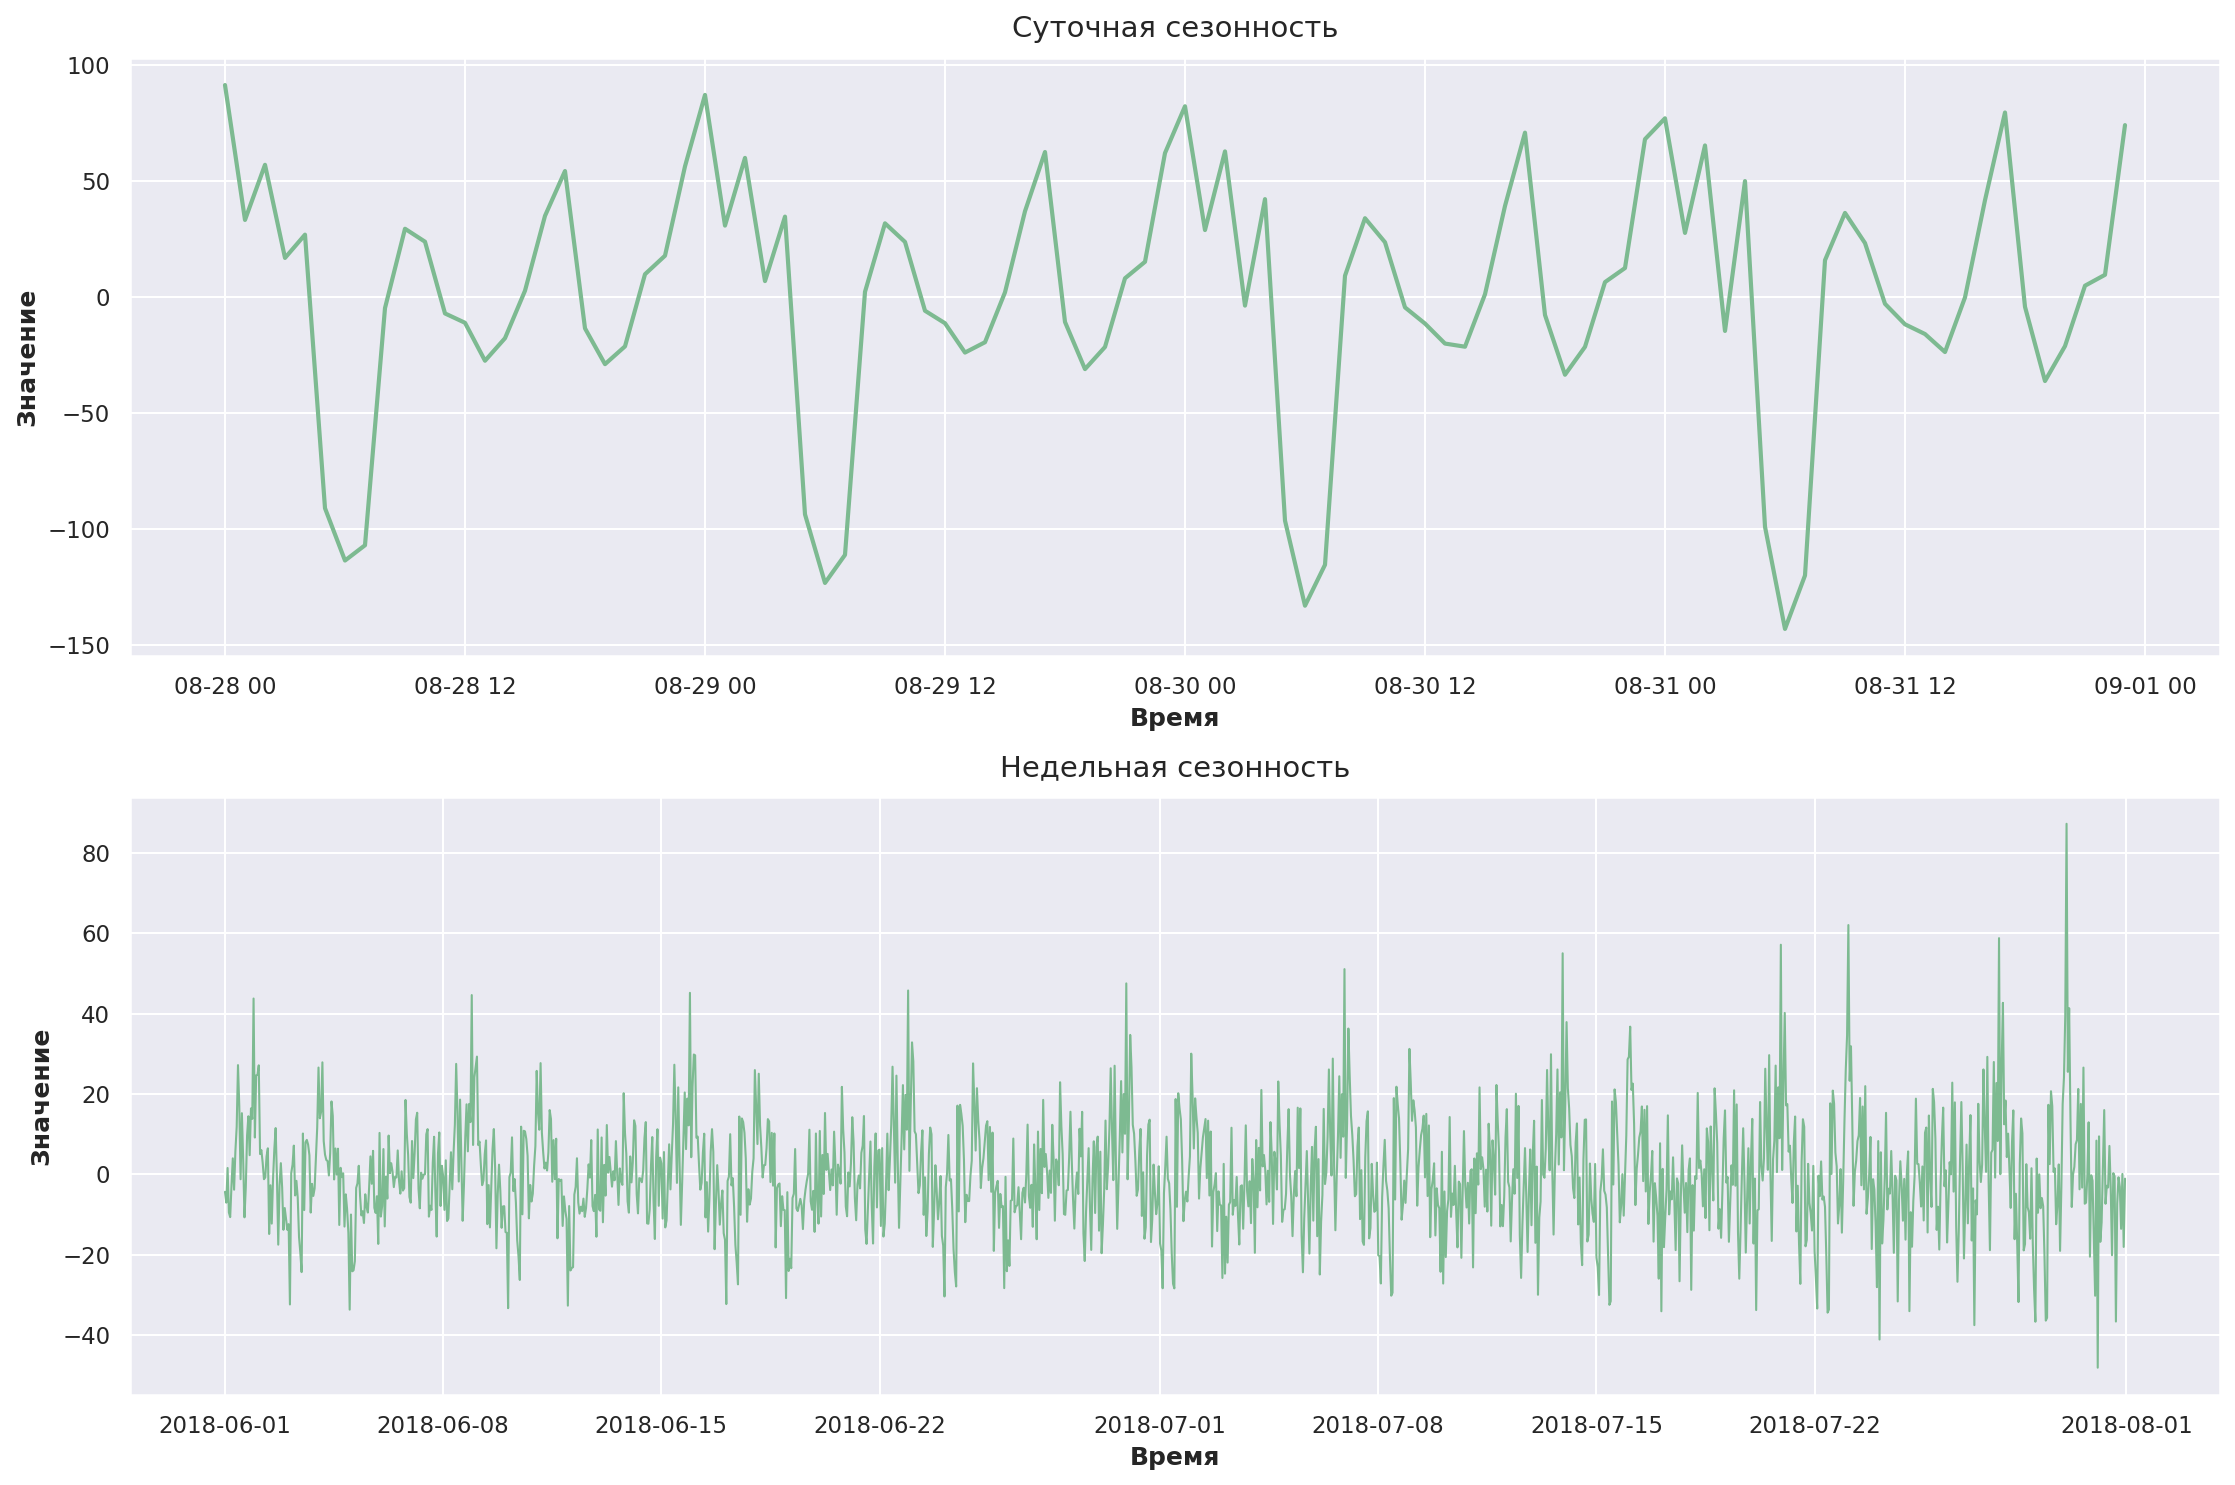

In [17]:
fig, ax = plt.subplots(figsize=(15,10), dpi=PLOT_DPI, nrows=2)

# график суточной сезонности
sns.lineplot(data=decomposed.seasonal.seasonal_24['2018-08-28':'2018-08-31'], linewidth=2, ax=ax[0])
ax[0].set_title('Суточная сезонность', fontsize=14) 
ax[0].set_xlabel('Время')
ax[0].set_ylabel('Значение')

# график недельной сезонности
sns.lineplot(data=decomposed.seasonal.seasonal_168['2018-06-01':'2018-07-31'], linewidth=1, ax=ax[1])
ax[1].set_title('Недельная сезонность', fontsize=14) 
ax[1].set_xlabel('Время')
ax[1].set_ylabel('Значение')

plt.tight_layout()
plt.show()

<font size="3">
    
**Вывод**
    
- `тренд` - на графике подтверждается растущий тренд с апреля 2018 года;
- `сезонность` - в выборке имеются данные только за 6 месяцев, что мешает определить, связан ли тренд с определённым сезоном;
- `остатки` - остатки усиливаются к концу периода, также наблюдаются отмеченные ранее пики в агусте.
    
Дополнительно изучена подробнее суточная сезонность: 
- на графике отмечается `суточная сезонность`: наибольший спрос приходится в период с 00:00 до 01:00, наименьший — с 5:00 до 07:00;
- также прослеживается `недельная сезонность`, учтём это при написании моделей.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> Компоненты ряда исследованы.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

### Стационарность временного ряда
    
<font size="3">   
<br>Напишем функцию для проверки стационарности ряда с помощью теста Дики-Фуллера:

- нулевая гипотеза ($H_0$): временной ряд нестационарный;
- альтернативная гипотеза ($H_1$): временной ряд стационарный. 
    
Дополнительно выведем график автокорреляционной функции.

In [18]:
# извлечём временной ряд
ts = taxi['num_orders']

def check_stationarity(series):
    # проведём тест ADF
    result = adfuller(series, regression='ct') # учтём константу и тренд
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Used Lag: %d' % result[2])
    print('Number of Observations Used: %d' % result[3])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
        
    # интерпретируем результаты
    if result[1] <= 0.05:
        print("\u001b[32mРяд стационарен\u001b[0m")
    else:
        print("\x1b[31mРяд нестационарен\x1b[0m")
         
    # построим ACF
    fig, ax = plt.subplots(figsize=(15,3), dpi=PLOT_DPI)
    plot_acf(series, ax=ax, lags=72, zero=False, title='Автокорреляция количества заказов в час')
    ax.set_ylim(-0.4,)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation');

ADF Statistic: -8.326522
p-value: 0.000000
Used Lag: 30
Number of Observations Used: 4385
Critical Values:
	1%: -3.961
	5%: -3.411
	10%: -3.128
Ряд стационарен


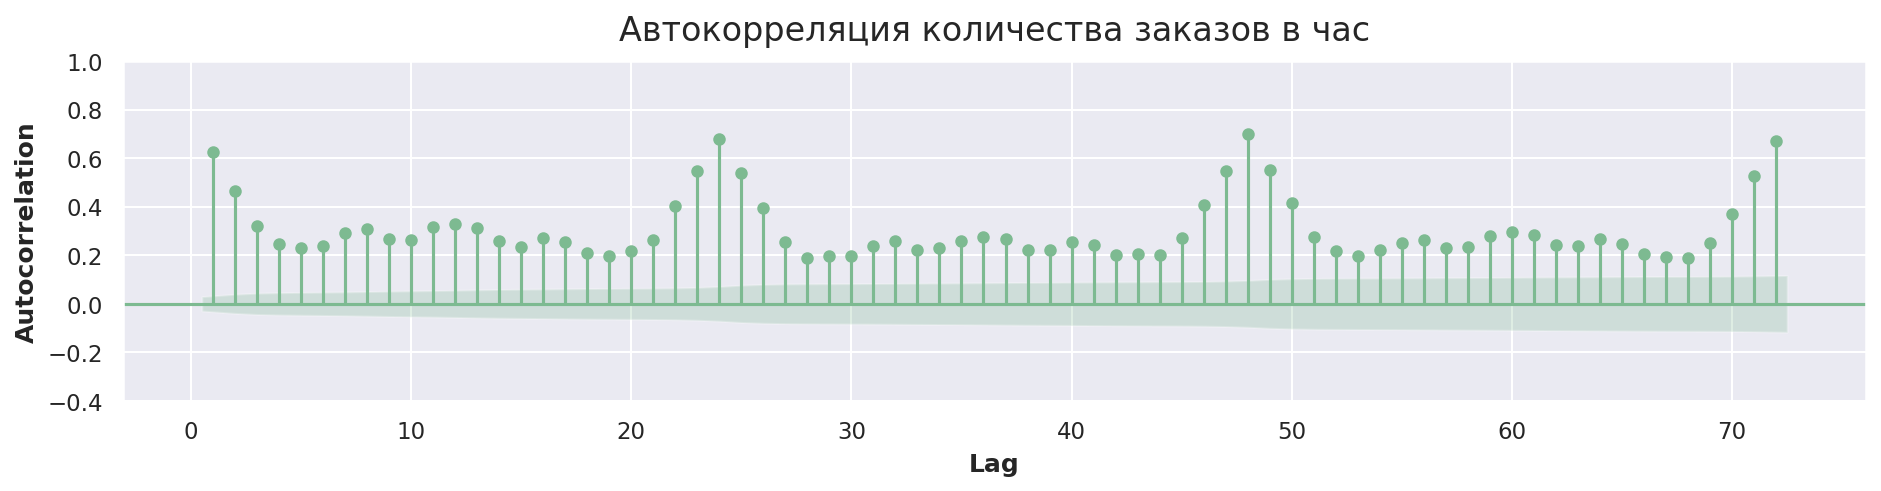

In [19]:
check_stationarity(ts)

<font size="3">  
    
На основе полученных результатов можно сделать следующие выводы:

- `ADF Statistic:` значение тестовой статистики в **-8.326522** значительно меньше критических значений, что указывает на сильные основания для отклонения нулевой гипотезы;
- `p-value:` полученное значение в **1.26e-11** значительно меньше заданного уровня значимости, что показывает вероятность получения таких данных, если нулевая гипотеза (наличие единичного корня) верна.
        
Несмотря на то, что ряд становится стационарным после удаления тренда и константы, это не означает, что он стационарен по своей природе. При более строгом уровне значимости не получается отвергнуть нулевую гипотезу без учета тренда. 
    
<br> На графике ACF корреляция постоянно положительная, что также говорит о наличии тренда. Дополнительно можно отметить, что лаг 24 сильнее всего коррелирует с исходным рядом, больше соседних лагов 23 и 25. Тоже самое можно сказать и про лаг 48 и 72. Такая автокорреляция позволяет предположить наличие сезонных колебаний.

График автокорреляционной функции согласуется с тем, что мы узнали о данных, когда раскладывали их на компоненты и говорит о том, что ряд имеет слабый тренд. 
    
Для дополнительной проверки стационарности временного ряда проведём тест KPSS, который проверяет обратную гипотезу:

- нулевая гипотеза ($H_0$): временной ряд стационарный;
- альтернативная гипотеза ($H_1$): временной ряд нестационарный.

In [20]:
def test_kpss(series):
    # проведём тест KPSS
    result = kpss(series)
    
    # выведем результат
    print('KPSS Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Number of Lags Used: %d' % result[2])
    print('Critical Values:')
    for key, value in result[3].items():
        print('\t%s: %.3f' % (key, value))

    # интерпретируем результат    
    if result[1] <= 0.05:
        print("\x1b[31mОтвергаем нулевую гипотезу, ряд нестационарен\x1b[0m")
    else:
        print("\u001b[32mНе отвергаем нулевую гипотезу, ряд стационарен\u001b[0m")

In [21]:
test_kpss(ts)

KPSS Statistic: 10.913353
p-value: 0.010000
Number of Lags Used: 32
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
Отвергаем нулевую гипотезу, ряд нестационарен


<font size="3">  

**Вывод**

Тест `KPSS` работает противоположно тесту `ADF`: он стремится подтвердить, что ряд стационарный. По результатам проверки нулевая гипотеза о стационарности ряда была отвергнута.
    
Временной ряд нестационарен, учтём это при выборе моделей и их конфигурации.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> Хорошее исследование стационарности ряда с помощью тестов. Молодец, что не забываешь формулировать гипотезы.

<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Технически работа по приведению ряда к стационарному выполнена отлично, но не очень поятна её связь с исследованием: ряд действительно стал более стационарным, но зачем мы это сделали, раз дальше работаем с обычным рядом, не очень понятно. 

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Да, убрала этот блок, не пригодился дальше в исследовании 🙌🏼
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено. 
    
Нестационарность ряда не мешает нам с ним работать: потенциально при работе с нестационарным рядом ошибка прогноза может быть выше, но работать с ним мы всё ещё можем. А вот со сдвигом не всё так просто: ряд разностей действительно более стационарен, но работа с ним отклоняет нас от исходной цели проекта - заказчик хочет предсказывать заказы в следующий час, а не разницу между заказами следущего и текущего часа. 
    
Соответственно тут есть два возможных вариант дальнейшей работы с рядом:
- продолжаем работать с исходным рядом: частично он сглаживается и становится более прогнозируемым за счёт скользящей средней в твоей функции по созданию новых признаков (если интересно почитать про другие техники сглаживания - можно посмотреть эту хорошую статью: https://habr.com/ru/companies/ods/articles/327242/);
- работать с рядом разниц, но тогда нужно писать решение, которое будет предсказывать ряд разниц, но оценивать качество предсказания будет на исходном ряде - для этого перед оценкой качества предсказаний (на кросс-валидации и на `test`) нужно делать обратное преобразование ряда, чтобы ряд разниц снова стал исходным рядом (более трудоёмкий вариант, но если есть желание - можно заняться реализацией).

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

## Подготовка данных

<font size="3"> 

Разделим данные на обучающую и тестовую выборки. На тест выделим 10% от исходных данных.

In [22]:
# разделим данные на обучающую и тестовую выборки
train_size = int(len(taxi) * 0.9)
train, test = taxi.iloc[:train_size], taxi.iloc[train_size:]

In [23]:
# проверка начальных и конечных значений индексов выборок
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())
print('\n')

# проверка размерности выборок
for x in ['train', 'test']:
    print(f'Размерность {x}: {globals()[x].shape} - {len(globals()[x])/len(taxi):.0%}')

# проверка упорядоченности индексов выборок
train.index.is_monotonic_increasing, test.index.is_monotonic_increasing

2018-03-01 00:00:00 2018-08-13 13:00:00
2018-08-13 14:00:00 2018-08-31 23:00:00


Размерность train: (3974, 1) - 90%
Размерность test: (442, 1) - 10%


(True, True)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
Сплитование выполнено корректно как с точки зрения учёта специфики временного ряда (отключено перемешивание), так и размера тестовой выборки. Также выделили признаки для обучения и целевой признак - хорошо!
</div>

<font size="3"> 

Подготовим тренировочную выборку для моделей.

In [24]:
train = train.rename(columns={'num_orders': 'y'}) # переименуем таргет в y
train['ds'] = train.index # добавим столбец ds с временным рядом
train["unique_id"] = 1 # присвоим уникальный номер серии данных

In [25]:
# проверим результат
train.head(5)

,y,ds,unique_id
datetime,,,
2018-03-01 00:00:00,124,2018-03-01 00:00:00,1
2018-03-01 01:00:00,85,2018-03-01 01:00:00,1
2018-03-01 02:00:00,71,2018-03-01 02:00:00,1
2018-03-01 03:00:00,66,2018-03-01 03:00:00,1
2018-03-01 04:00:00,43,2018-03-01 04:00:00,1


In [26]:
# зададим размер прогноза
horizon = len(test)

<font size="3">  

**Вывод**

Отобраны и созданы признаки для построения прогноза. 
    
Выделены обучающая и тестовая выборки, учтён требуемый размер тестовой выборки. 

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3"> 
    
## Разработка моделей
    
В данном шаге исследования проведем сравнительный анализ моделей, обученных на следующих алгоритмах:

- `Prophet()`;
- `ARIMA()`;
- `Ridge()`;
- `RandomForestRegressor()`;
- `CatBoostRegressor()`.
    
Качество модели оценим с помощью метрики `RMSE`.
    
Для каждой модели добавим подбор гиперпараметров с помощью `Optuna`, для написания моделей воспользуемся библиотеками [Nixtla](https://nixtlaverse.nixtla.io/).

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
### `Prophet()`
    
<font size="3">
    
<br> Напишем функцию обучения модели с подбором гиперепараметров, учтём суточную и недельную сезонность и добавим календарь праздничных дней.

In [27]:
# получим выходные за 2018 год
russian_holidays = holidays.RU(years=[2018], observed=True)

In [28]:
# создадим таблицу с выходными
holidays_df = pd.DataFrame({
    'ds': pd.to_datetime(list(russian_holidays.keys())),
    'holiday': list(russian_holidays.values())
})

In [29]:
# проверим результат
holidays_df.head()

,ds,holiday
0,2018-01-01,New Year Holidays
1,2018-01-02,New Year Holidays
2,2018-01-03,New Year Holidays
3,2018-01-04,New Year Holidays
4,2018-01-05,New Year Holidays


In [30]:
def objective_prophet(trial):
    # укажем гиперпараметры для перебора
    params_prophet = {
        'changepoint_range': trial.suggest_float("changepoint_range", 0.8, 0.99),
        'n_changepoints': trial.suggest_int("n_changepoints", 5, 20),
        'seasonality_mode': trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10.0),
        'growth': trial.suggest_categorical("growth", ['linear', 'flat']), 
        "weekly_seasonality": True,
        "daily_seasonality": True,
        "holidays": holidays_df
    }
    
    # TimeSeriesSplit для кросс-валидации
    tscv = TimeSeriesSplit(n_splits=5)
    rmse_values = []
    
    # проходимся по фолдам TimeSeriesSplit
    for train_index, test_index in tscv.split(train):
        # используем train_index для обучения и test_index для прогнозирования
        X_train_fold = train.iloc[train_index]
        X_test_fold = train.iloc[test_index]

        # создаём новый экземпляр модели для каждого фолда
        model_prophet = Prophet(**params_prophet)

        # обучаем модель на тренировочных данных
        model_prophet.fit(X_train_fold)

        # делаем прогноз на тестовых данных
        future = model_prophet.make_future_dataframe(periods=len(X_test_fold), freq='H')
        predictions = model_prophet.predict(future)
        
        forecast = X_test_fold.copy()
        forecast = forecast.merge(predictions[['ds', 'yhat']], on='ds', how='left')
        
         # рассчитываем RMSE для текущего фолда
        rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
        rmse_values.append(rmse) 

    # возвращаем среднее значение RMSE по всем фолдам
    return np.mean(rmse_values)

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
Молодец, что учитываешь специфику задачи временного ряда при выборе стратегии кросс-валидации: `TimeSeriesSplit` - отличное решение!

In [31]:
# создадим объект study
study_prophet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=10)) 

[I 2024-09-19 14:26:24,765] A new study created in memory with name: no-name-9af9f073-796e-4208-9612-313fd40e29a4


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку❌:</b> Не забывай фиксировать `random_state` у `Optuna` - например, так:
    
    study = optuna.create_study(..., sampler=optuna.samplers.TPESampler(seed=10))


<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Исправилась 🙌🏼
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено. 

In [32]:
# запустим процесс оптимизации
study_prophet.optimize(objective_prophet, n_trials=50)

[I 2024-09-19 14:26:36,267] Trial 0 finished with value: 26.46222006035041 and parameters: {'changepoint_range': 0.9465509222206817, 'n_changepoints': 5, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 4.990085052902878, 'growth': 'linear'}. Best is trial 0 with value: 26.46222006035041.
[I 2024-09-19 14:26:46,816] Trial 1 finished with value: 32.46623498084658 and parameters: {'changepoint_range': 0.9445008353178022, 'n_changepoints': 7, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 9.534399528487416, 'growth': 'flat'}. Best is trial 0 with value: 26.46222006035041.
[I 2024-09-19 14:26:58,141] Trial 2 finished with value: 25.957226419556758 and parameters: {'changepoint_range': 0.9543979827139015, 'n_changepoints': 14, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 9.178563483904306, 'growth': 'linear'}. Best is trial 2 with value: 25.957226419556758.
[I 2024-09-19 14:27:09,154] Trial 3 finished with value: 25.945210004290754 and paramet

In [33]:
time_prophet = study_prophet.best_trial.duration.total_seconds()
rmse_prophet = study_prophet.best_value

# выведем метрику лучшей модели
print('RMSE на кросс-валидации:')
rmse_prophet

RMSE на кросс-валидации:


25.914131644028238

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации⚠️:</b> Обрати внимание, что не существует кросс-валидационной выборки. Есть или оценка, полученная на `valid` выборке, или оценка, полученная с помощью кросс-валидации.

<font size="3">
    
**Вывод**
    
На данном этапе исследования написана модель `Prophet()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `RMSE`:
    
Метрика **RMSE** на кросс-валидации: **26**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
### `ARIMA()`
    
<font size="3">
    
<br> Напишем модель с подбором гиперепараметров с помощью `AutoARIMA()` с добавлением сезонности.

In [34]:
# суточная сезонность
season_length = 24

# ARIMA с авто-подбором параметров и сезонностью 
models = [AutoARIMA(season_length=season_length)] 

# инициализируем класс StatsForecast
sf = StatsForecast(
    models=models,
    freq='H',  
    n_jobs=-1  
)

In [35]:
# измерим время обучения
start_time = time.time()

# обучим модель
sf.fit(train)

end_time = time.time()

In [36]:
# выведем лучшие параметры модели
arima_string(sf.fitted_[0,0].model_)

'ARIMA(5,0,1)(2,1,0)[24]                   '

In [37]:
# получим метрику модели с помощью кросс-валидации
cv_arima = sf.cross_validation(
    df=train,
    h=horizon,
    n_windows=4,
)

In [38]:
time_arima = end_time - start_time # время обучения
rmse_arima = datasets_rmse(cv_arima['y'], cv_arima["AutoARIMA"]) # метрика модели

# выведем метрику лучшей модели
print("RMSE на кросс-валидации: ", rmse_arima)

RMSE на кросс-валидации:  35.75226


<font size="3">
    
**Вывод**
    
На данном этапе исследования написана модель `ARIMA()` с подбором гиперпараметров, лучшие параметры модели оценивались с помощью метрики `RMSE`:
    
Метрика **RMSE** на кросс-валидации: **35**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
### `AutoMLForecast()`
    
<font size="3">
    
<br> Для ML-моделей воспользуемся `AutoMLForecast()`, который поможет перебрать гиперпараметры с помощью `Optuna` и добавить дополнительные признаки в тренировочную выборку.

In [39]:
# создание дополнительных признаков 
def my_init_config(trial: optuna.Trial):
        return {
            'date_features':['hour', 'weekday'], # годовая и месячная сезонность в данных отсутствуют, добавим час и день недели
            'lags': [1,24,48,72,96, 120, 144, 168], # лаги ограничим значением 168 (24 *7)
            'target_transforms': [LocalStandardScaler()], # скалируем таргет
            'lag_transforms': {
                1: [  # преобразования для лага 1
                    RollingMean(window_size=3),  # скользящее среднее с окном 3 временных шага
                    RollingStd(window_size=3),  # скользящее стандартное отклонение с окном 3 временных шага
                    RollingMin(window_size=3),  # скользящий минимум с окном 3 временных шага
                    RollingMax(window_size=3),  # скользящий максимум с окном 3 временных шага
                    RollingQuantile(p=0.5, window_size=3),  # скользящая медиана с окном 3 временных шага
                    ExpandingMean()  # среднее всех предыдущих значений
                ],
                24:[  # преобразования для лага 24
                    RollingMean(window_size=7),  # скользящее среднее с окном 7 временных шагов
                    RollingStd(window_size=7),  # скользящее стандартное отклонение с окном 7 временных шагов
                    RollingMin(window_size=7),  # скользящий минимум с окном 7 временных шагов
                    RollingMax(window_size=7),  # скользящий максимум с окном 7 временных шагов
                    RollingQuantile(p=0.5, window_size=6),  # скользящая медиана с окном 7 временных шагов
                ],
                168: [  # преобразования для лага 168 
                    SeasonalRollingMean(season_length=168, window_size=3),  # сезонное скользящее среднее с 1-недельной сезонностью и окном в 3 временных шага 
                    SeasonalRollingStd(season_length=168, window_size=3),  # сезонное скользящее стандартное отклонение с 1-недельной сезонностью и окном в 3 временных шага
                    SeasonalRollingMin(season_length=168, window_size=3),  # сезонный скользящий минимум с 1-недельной сезонностью и окном в 3 временных шага
                    SeasonalRollingMax(season_length=168, window_size=3),  # сезонный скользящий максимум с 1-недельной сезонностью и окном в 3 временных шага
                    SeasonalRollingQuantile(p=0.5, season_length=168, window_size=3)  # сезонная скользящая медиана с 1-недельной сезонностью и окном в 3 временных шага
                ]
            },
            
                }

# конфигурация обучения
def my_fit_config(trial: optuna.Trial):
        return {
            'static_features': ['unique_id'] # зададим статичные признаки
        }

# функция потерь
def loss(df, train_df):
    return utils_rmse(df, models=["model"])["model"].mean() # метрика RMSE

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
#### `Ridge()`
    
<font size="3">
    
<br> Напишем функцию обучения модели с подбором гиперепараметров.

In [40]:
# функция для подбора гиперпараметров с помощью Optuna
def my_ridge_space(trial: optuna.Trial):
    # укажем гиперпараметры для перебора
    return {
        "alpha": trial.suggest_loguniform('alpha', 1e-5, 1e2),
        "solver": trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky']),
        "random_state": RANDOM_STATE
    }

# инициализируем AutoMLForecast для Ridge
auto_mlf_ridge = AutoMLForecast(
        freq="H",
        season_length=24,
        models={
            'Ridge': AutoRidge(config = my_ridge_space)
        },
        init_config=my_init_config,
        fit_config=my_fit_config
    )

In [41]:
# обучим модель Ridge
auto_mlf_ridge.fit(
        df=train,
        n_windows=7,
        h=horizon,
        num_samples=50,
        loss = loss,
        refit = True
    )

[I 2024-09-19 15:03:07,098] A new study created in memory with name: no-name-e0ff4c34-6af6-4c72-8e67-d6ca6bf106d3
[I 2024-09-19 15:03:29,392] Trial 0 finished with value: 23.08436310188466 and parameters: {'alpha': 0.0694535625742477, 'solver': 'auto'}. Best is trial 0 with value: 23.08436310188466.
[I 2024-09-19 15:03:51,778] Trial 1 finished with value: 23.16530226228756 and parameters: {'alpha': 0.009238119916812988, 'solver': 'cholesky'}. Best is trial 0 with value: 23.08436310188466.
[I 2024-09-19 15:04:15,057] Trial 2 finished with value: 22.670281956700542 and parameters: {'alpha': 55.67232047731105, 'solver': 'svd'}. Best is trial 2 with value: 22.670281956700542.
[I 2024-09-19 15:04:38,018] Trial 3 finished with value: 23.06128663655042 and parameters: {'alpha': 0.09469170308457585, 'solver': 'auto'}. Best is trial 2 with value: 22.670281956700542.
[I 2024-09-19 15:05:01,460] Trial 4 finished with value: 23.182501283692226 and parameters: {'alpha': 1.3852519879556075e-05, 'sol

AutoMLForecast(models={'Ridge': AutoModel(model=Ridge)})

In [42]:
time_ridge = auto_mlf_ridge.results_['Ridge'].best_trial.duration.total_seconds() # время обучения
rmse_ridge = round(auto_mlf_ridge.results_['Ridge'].best_trial.values[0], 3) # метрика модели

# выведем метрику лучшей модели
print('RMSE на кросс-валидации:')
rmse_ridge

RMSE на кросс-валидации:


22.653

<font size="3">
    
**Вывод**
    
На данном этапе исследования написана модель `Ridge()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `RMSE`:
    
Метрика **RMSE** на кросс-валидации: **23**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
#### `RandomForestRegressor()`
    
<font size="3">
    
<br> Напишем функцию обучения модели с подбором гиперепараметров.

In [43]:
# функция для подбора гиперпараметров с помощью Optuna
def my_forest_space(trial: optuna.Trial):
    # укажем гиперпараметры для перебора
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 10),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        "random_state": RANDOM_STATE
    }

# инициализируем AutoMLForecast для RandomForest
auto_mlf_forest = AutoMLForecast(
        freq="H",
        season_length=24,
        models={
            'RandomForest': AutoRandomForest(config=my_forest_space)
        },
        init_config=my_init_config,
        fit_config=my_fit_config
    )

In [44]:
# обучим модель RandomForest
auto_mlf_forest.fit(
        df=train,
        n_windows=7,
        h=horizon,
        num_samples=50,
        loss = loss,
        refit = True
    )

[I 2024-09-19 15:14:19,348] A new study created in memory with name: no-name-276a207a-512a-484d-8e41-6b6ca659c9ff
[I 2024-09-19 15:15:35,354] Trial 0 finished with value: 23.604431542777643 and parameters: {'n_estimators': 320, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 23.604431542777643.
[I 2024-09-19 15:17:16,061] Trial 1 finished with value: 23.519548704526233 and parameters: {'n_estimators': 486, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 23.519548704526233.
[I 2024-09-19 15:17:56,950] Trial 2 finished with value: 23.635750354502562 and parameters: {'n_estimators': 108, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 23.519548704526233.
[I 2024-09-19 15:18:44,945] Trial 3 finished with value: 23.5797815399725

AutoMLForecast(models={'RandomForest': AutoModel(model=RandomForestRegressor)})

In [45]:
time_forest = auto_mlf_forest.results_['RandomForest'].best_trial.duration.total_seconds() # время обучения
rmse_forest = round(auto_mlf_forest.results_['RandomForest'].best_trial.values[0], 3) # метрика модели

# выведем метрику лучшей модели
print('RMSE на кросс-валидации:')
rmse_forest

RMSE на кросс-валидации:


23.16

<font size="3">
    
**Вывод**
    
На данном этапе исследования написана модель `RandomForestRegressor()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `RMSE`:
    
Метрика **RMSE** на кросс-валидации: **23**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
#### `CatBoostRegressor()`
    
<font size="3">
    
<br> Напишем функцию обучения модели с подбором гиперепараметров.

In [46]:
# функция для подбора гиперпараметров с помощью Optuna
def my_catboost_space(trial: optuna.Trial):
    # укажем гиперпараметры для перебора
    return {
        'iterations': trial.suggest_int("iterations", 100, 500),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        'depth': trial.suggest_int("depth", 4, 8),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1, 10),
        'random_strength': trial.suggest_float("random_strength", 1, 5),
        "logging_level": 'Silent',
        "random_state": RANDOM_STATE
    }

# инициализируем AutoMLForecast для CatBoost
auto_mlf_cat = AutoMLForecast(
        freq="H",
        season_length=24,
        models={
            'CatBoost': AutoCatboost(config=my_catboost_space, )
        },
        init_config=my_init_config,
        fit_config=my_fit_config
    )

In [47]:
# обучим модель CatBoost
auto_mlf_cat.fit(
        df=train,
        n_windows=7,
        h=horizon,
        num_samples=50,
        loss = loss,
        refit = True
    )

[I 2024-09-19 15:40:49,777] A new study created in memory with name: no-name-fe673d53-e082-426b-af00-43e11714975b
[I 2024-09-19 15:41:35,130] Trial 0 finished with value: 23.818460903477384 and parameters: {'iterations': 320, 'learning_rate': 0.051902630176951646, 'depth': 7, 'l2_leaf_reg': 5.903948646972072, 'random_strength': 2.694619197355619}. Best is trial 0 with value: 23.818460903477384.
[I 2024-09-19 15:42:39,026] Trial 1 finished with value: 23.257344836111987 and parameters: {'iterations': 359, 'learning_rate': 0.027389695952346985, 'depth': 8, 'l2_leaf_reg': 9.672964844509263, 'random_strength': 2.533766075303111}. Best is trial 1 with value: 23.257344836111987.
[I 2024-09-19 15:43:20,950] Trial 2 finished with value: 23.566476538495653 and parameters: {'iterations': 417, 'learning_rate': 0.0337983049214134, 'depth': 6, 'l2_leaf_reg': 9.330369744633948, 'random_strength': 1.2841442327915478}. Best is trial 1 with value: 23.257344836111987.
[I 2024-09-19 15:44:02,559] Trial 3

AutoMLForecast(models={'CatBoost': AutoModel(model=CatBoostRegressor)})

In [48]:
time_cat = auto_mlf_cat.results_['CatBoost'].best_trial.duration.total_seconds() # время обучения
rmse_cat = round(auto_mlf_cat.results_['CatBoost'].best_trial.values[0], 3) # метрика модели

# выведем метрику лучшей модели
print('RMSE на кросс-валидации:')
rmse_cat

RMSE на кросс-валидации:


23.015

<font size="3">
    
**Вывод**
    
На данном этапе исследования написана модель `CatBoostRegressor()` с подбором гиперпараметров, который определил лучшие параметры модели с помощью метрики `RMSE`:
    
Метрика **RMSE** на кросс-валидации: **23**

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
## Выбор лучшей модели
    
<font size="3">
    
<br> Для удобства соберём полученные метрики моделей в сравнительную таблицу.

In [49]:
results = pd.DataFrame(
    {'Модели': ['Prophet', 'ARIMA', 'Ridge', 'RandomForest', 'CatBoost'], 
     'RMSE на CV': [rmse_prophet, rmse_arima, rmse_ridge, rmse_forest, rmse_cat],
     'Время обучения': [time_prophet, time_arima, time_ridge, time_forest, time_cat],
    })

results

,Модели,RMSE на CV,Время обучения
0,Prophet,25.914,11.607
1,ARIMA,35.752,261.608
2,Ridge,22.653,22.307
3,RandomForest,23.160,90.479
4,CatBoost,23.015,66.707


<font size="3"> 
    
Все модели за исключением `ARIMA()` показали хороший результат на кросс-валидации, метрика `RMSE` составила **~23**. 
    
Для построения прогноза учтём также время обучения моделей и для получения прогноза выберем модель `Ridge()`, которая показала оптимальное соотношение скорости обучения и качества прогноза.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍</b> Есть сравнительный анализ моделей, отлично!

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="4">
    
**Анализ качества предсказания модели на тестовой выборке**

<font size="3"> Получим метрику лучшей модели на тестовой выборке.

In [50]:
# получим прогноз модели с лучшими параметрами
y_pred = auto_mlf_ridge.predict(horizon)

# получим метрики на тестовом наборе
rmse = mean_squared_error(test['num_orders'], y_pred['Ridge'], squared=False)

# выведем результат
print('Метрика лучшей модели на тестовой выборке:')
rmse

Метрика лучшей модели на тестовой выборке:


40.587842119449355

<font size="3"> 

**Вывод**
    
Значение метрики `RMSE` на тестовой выборке соответствует установленному заказчиком максимальному порогу в **48**, что делает выбранную модель пригодной для получения прогноза.

<div class="alert alert-success">
    
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Лучшую модель оценили на `test` - отличный результат!

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="4">
    
**Проверка модели на адекватность**

<font size="3"> Для оценки адекватности лучшей модели создадим константную модель `DummyRegressor`, которая будет предсказывать константу: среднее значение тренировочной выборки. 

In [51]:
# Создайте модель DummyRegressor
dummy_model = DummyRegressor(strategy='mean') 

# Обучите модель на обучающих данных
dummy_model.fit(train[['ds']], train['y'])

# Сделайте предсказание на тестовых данных
predictions = dummy_model.predict(test.index)

# Вычислите RMSE
rmse = mean_squared_error(test['num_orders'], predictions, squared=False)

print(f"RMSE DummyRegressor: {rmse}")

RMSE DummyRegressor: 84.74414402014742


<font size="3"> 

**Вывод**
    
Модель `Ridge` справляется c предсказанием спроса на такси значительно лучше константной модели `DummyRegressor`, предсказывающей среднее значение тренировочной выборки.
    
Лучшая модель исследования является адекватной и может быть использована для получения прогноза.

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="4">
    
**Визуализация полученного прогноза**

<font size="3">
      
Отобразим полученные результаты на графике и оценим прогноз лучшей модели.

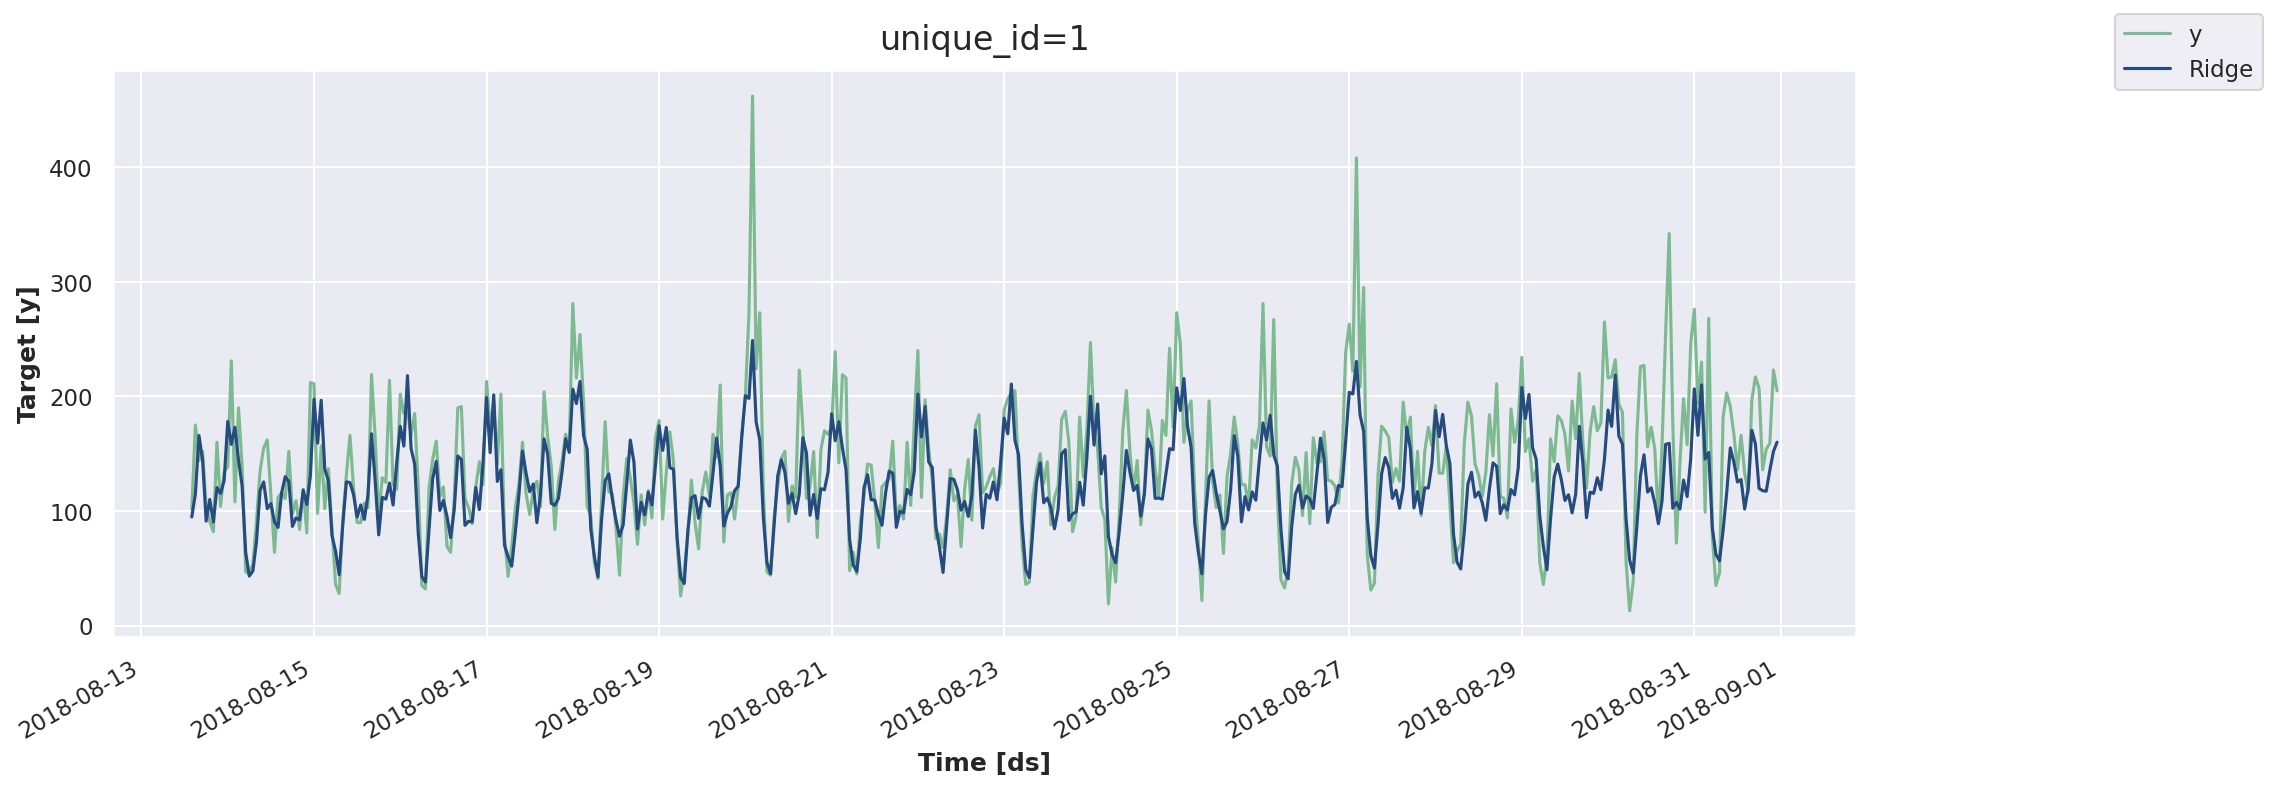

In [52]:
# объединим факт и прогноз для построения графика
df_combined = pd.merge(test, y_pred, left_index=True, right_on='ds')
df_combined = df_combined.rename(columns={'num_orders': 'y'})

# визуализируем результат прогнозирования
fig, ax = plt.subplots(figsize=(15,5), dpi=PLOT_DPI)
plot_series(forecasts_df=df_combined, ax=ax)

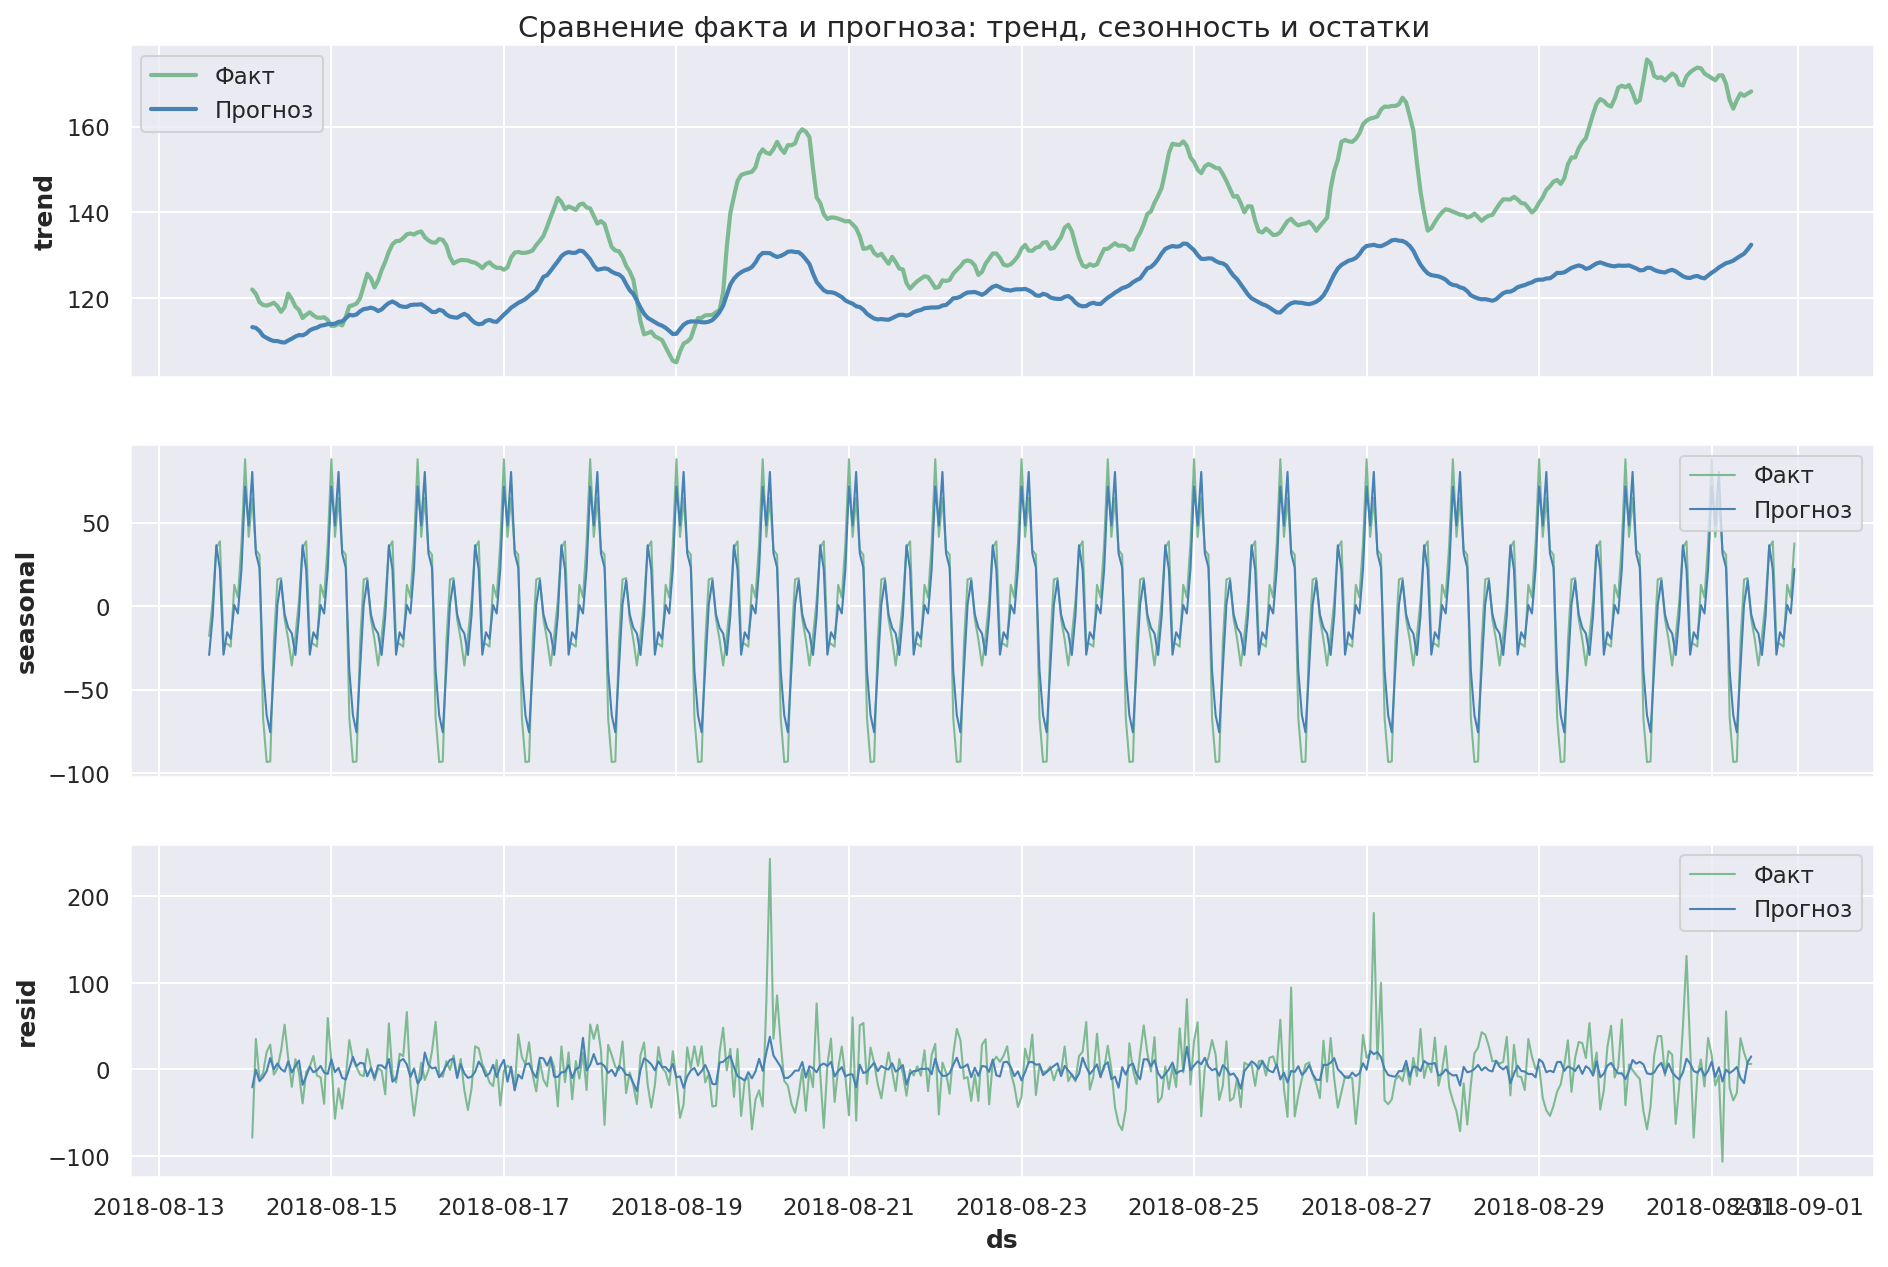

In [53]:
# подготовим данные к визуализации
df_combined.set_index('ds', inplace=True)
df_combined.drop(columns='unique_id', inplace=True)

# разложим полученные данные с помощью seasonal_decompose
decomposed_true = seasonal_decompose(df_combined['y'])
decomposed_pred = seasonal_decompose(df_combined['Ridge'])

# построим графики
fig, ax = plt.subplots(figsize=(15, 10), dpi=PLOT_DPI, nrows=3, sharex=True)

# тренд
sns.lineplot(data=decomposed_true.trend, linewidth=2, label="Факт", ax=ax[0])
sns.lineplot(data=decomposed_pred.trend, linewidth=2, label="Прогноз", ax=ax[0], color='steelblue')

# сезонность
sns.lineplot(data=decomposed_true.seasonal, linewidth=1, label="Факт", ax=ax[1])
sns.lineplot(data=decomposed_pred.seasonal, linewidth=1, label="Прогноз", ax=ax[1], color='steelblue')

# остатки
sns.lineplot(data=decomposed_true.resid, linewidth=1, label="Факт", ax=ax[2])
sns.lineplot(data=decomposed_pred.resid, linewidth=1, label="Прогноз", ax=ax[2], color='steelblue')

plt.suptitle("Сравнение факта и прогноза: тренд, сезонность и остатки", fontsize=14, y=0.9)
plt.legend()
plt.show()

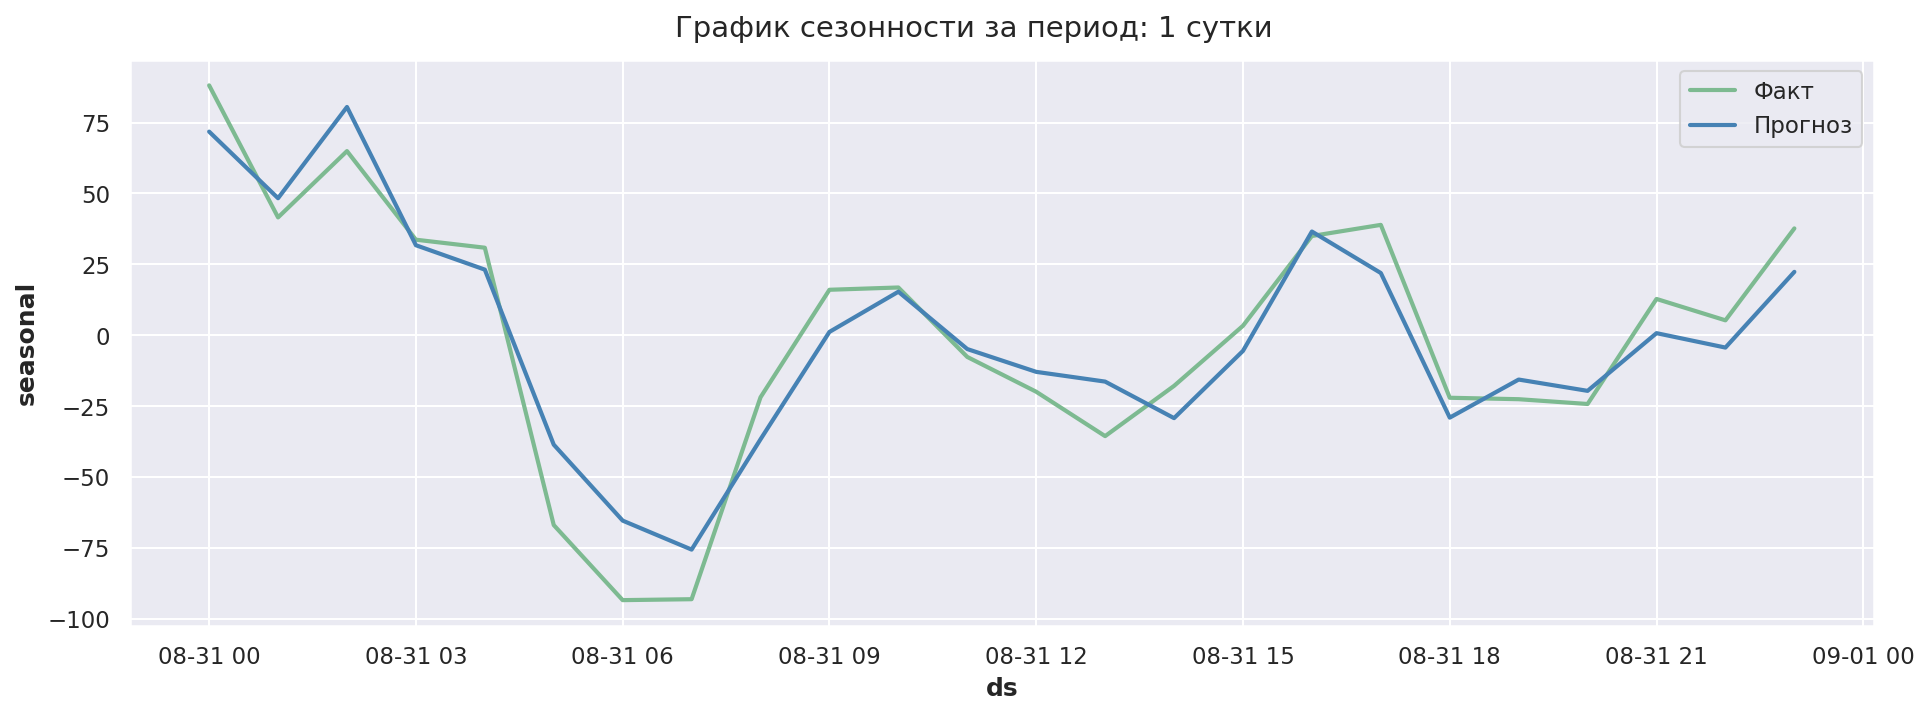

In [54]:
# построим график суточной сезонности
fig, ax = plt.subplots(figsize=(15,5), dpi=PLOT_DPI)

sns.lineplot(data=decomposed_true.seasonal['2018-08-31':'2018-08-31'], linewidth=2, label="Факт", ax=ax)
sns.lineplot(data=decomposed_pred.seasonal['2018-08-31':'2018-08-31'], linewidth=2, label="Прогноз", ax=ax, color='steelblue')

plt.suptitle("График сезонности за период: 1 сутки", fontsize=14, y=0.94)
plt.legend()
plt.show()

<font size="3"> 
    
**Вывод**
    
Предсказания модели приближены к фактическим значениям, но имеют более сглаженный характер. Большая часть ошибок вызвана аномально высокими значениями в данных. 
    
Можно отметить, что модель успешно выделила общий восходящий тренд, а также сезонность по времени суток.

<div class="alert alert-success">
    
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Круто, что сравниваешь реальные и предсказанные ответы в форме линейного графика - отличное решение для временных рядов.

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации⚠️:</b>
Очень важно также проверить лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки? 
    
В качестве константной модели можно использовать `DummyRegressor` (https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) -  эта модель как раз создана для генерирования константных предсказаний.
    
Важно, чтобы результат тестирования нашей модели на тествой выборке был лучше, чем результат константной модели - в противном случае наша модель является бесполезной, так как все наши усилия над проектом не принесли результата, а можель, просто предсказывющая среднее на `train`, делает нашу работу лучше.

<div class="alert alert-info">
<h2> Комментарий студента <a class="tocSkip"> </h2>

Добавила проверку на адекватность после получения метрики на тесте, спасибо🙌🏼 
</div>

<div class="alert alert-success">
<h2> Комментарий ревьюера v.2 <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Учтено. 

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">
    
## Общий вывод
    
<font size="3">
    
<br>Целью данного исследования являлась разработка модели МО, которая могла бы спрогнозировать количество заказов такси на следующий час.
    
**Подготовка данных**
    
- данные загружены;
- проведена начальная предобработка: данные проверены на пропуски, аномальные значения, монотонность;
- данные ресемплированы с интервалом в один час с суммированием количества заказов.
    
**Анализ целевого признака**  
- изучено распределение признака;
- получена и проанализирована информация о тренде, сезонности и остатках;
- временной ряд проанализирован на стационарность;
- получен временной ряд с линейным трендом в логарифмическом масштабе;
- получен стационарный временной ряд.

**Полученные выводы**    
- распределение признака асимметрично вправо, большинство значений располагается в промежутке от 54 до 107 заказов в час с пиком в районе 80 заказов;
- выявлен восходящий тренд среднего количества заказов такси с апреля по конец августа 2018 года;
- временной ряд признан нестационарным; 
- в августе отмечается 4 аномально высоких значений количества заказов;
- в данных отмечается недельная и суточная сезонности.
 
    
**Разработка моделей**      
<br> Написаны и обучены 5 моделей с подбором гиперпараметров: 
  - `Prophet`
  - `ARIMA`
  - `Ridge`
  - `RandomForest`
  - `CatBoost`
    
Лучшая модель выбрана с помощью метрики `RMSE` на кросс-валидации с учётом скорости обучения модели.
    
**Анализ лучшей модели** 
    
По результатам исследования лучшей признана модель `Ridge`, показавшая оптимальное соотношение скорости и качества прогноза.
    
Модель проверена на тестовых данных, полученна метрика `RMSE` - **40**, что соответствует заданному заказчиком порогу в 48.
    
**Заключение** 
       
Предсказания выбранной модели `Ridge` приближены к фактическим значениям, но имеют более сглаженный характер. Большая часть ошибок вызвана аномально высокими значениями в данных.

Можно отметить, что модель успешно выделила общий восходящий тренд, а также сезонность по времени суток.
    
**Рекомендации** 
    
- увеличить обучающую выборку: информация за 2-3 последних года поможет выявить годовую сезонность, данные за аналогичные сезоны прошлых лет могут повысить качество прогноза;
- изучить природу выявленных аномальных значений: если такие всплески спроса действительно были и их нельзя заменить на более разумные значения, можно рассмотреть более устойчивую к аномалиям метрику для оценки качества модели (например, MAE);
- попробовать иные модели (например, SARIMA или нейросеть).

<div style="border:solid Chocolate 2px; padding: 40px">

# Комментарий ревьюера: общий вывод по проекту.

Валерия, проект получился на довольно хорошем уровне - отличная работа над проектом, молодец!

Мне нравится твой аналитический подход к выполнению проекта, ты соблюдаешь структуру работы, выполняешь её последовательно - это очень хорошо! Шаги проекта выполнены по порядку согласно плану проекта, нет смысловых и структурных ям. Важно, что не забываешь про выводы.

Работа с моделями также выполнена отлично: круто, что удалось попробовать нетривиальные модели, а также использовать инструменты, выходящие за рамки курса! Здорово также, что учитываешь специфику задачи временного ряда при выборе стратегии кросс-валидации: `TimeSeriesSplit` - отличное решение!
    
Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.
    
Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)
    
Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.
    
Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)
    
Жду твой проект на повторном ревью. До встречи:)

<div style="border:solid Chocolate 2px; padding: 40px">

# Комментарий ревьюера: итоговый вывод по проекту.

Валерия, все замечания учтены - проект принят!
    
Спасибо за хорошую работу над проектом, желаю успехов в дальнейшем обучении:)